1. Choix et importation de la base de données,  
    OASIS 1 seulement utiliser 3 catégorie (Mild Dementia, Non Demented, Very Mild Dementia) J'ai 10 patient par catégorie
    Par patient, j'ai pris 25 slice (80 à 104 sur fichier.hdr)
2. Exploration et prétraitement des données, 
    J'ai repris le travail qu'on avait regarde avec Madhi.

3. Extraction et représentation des caractéristiques, 
4. Sélection des caractéristiques ou réduction de dimension, 
5. Choix et étude de l’algorithme d’apprentissage supervisé, 
    SVM
6. Étude des hyperparamètres et des variantes de l’algorithme, 
7. Évaluation des performances selon différentes stratégies de validation, 
8. Analyse et interprétation des résultats, 
9. Bilan critique de l’algorithme étudié.

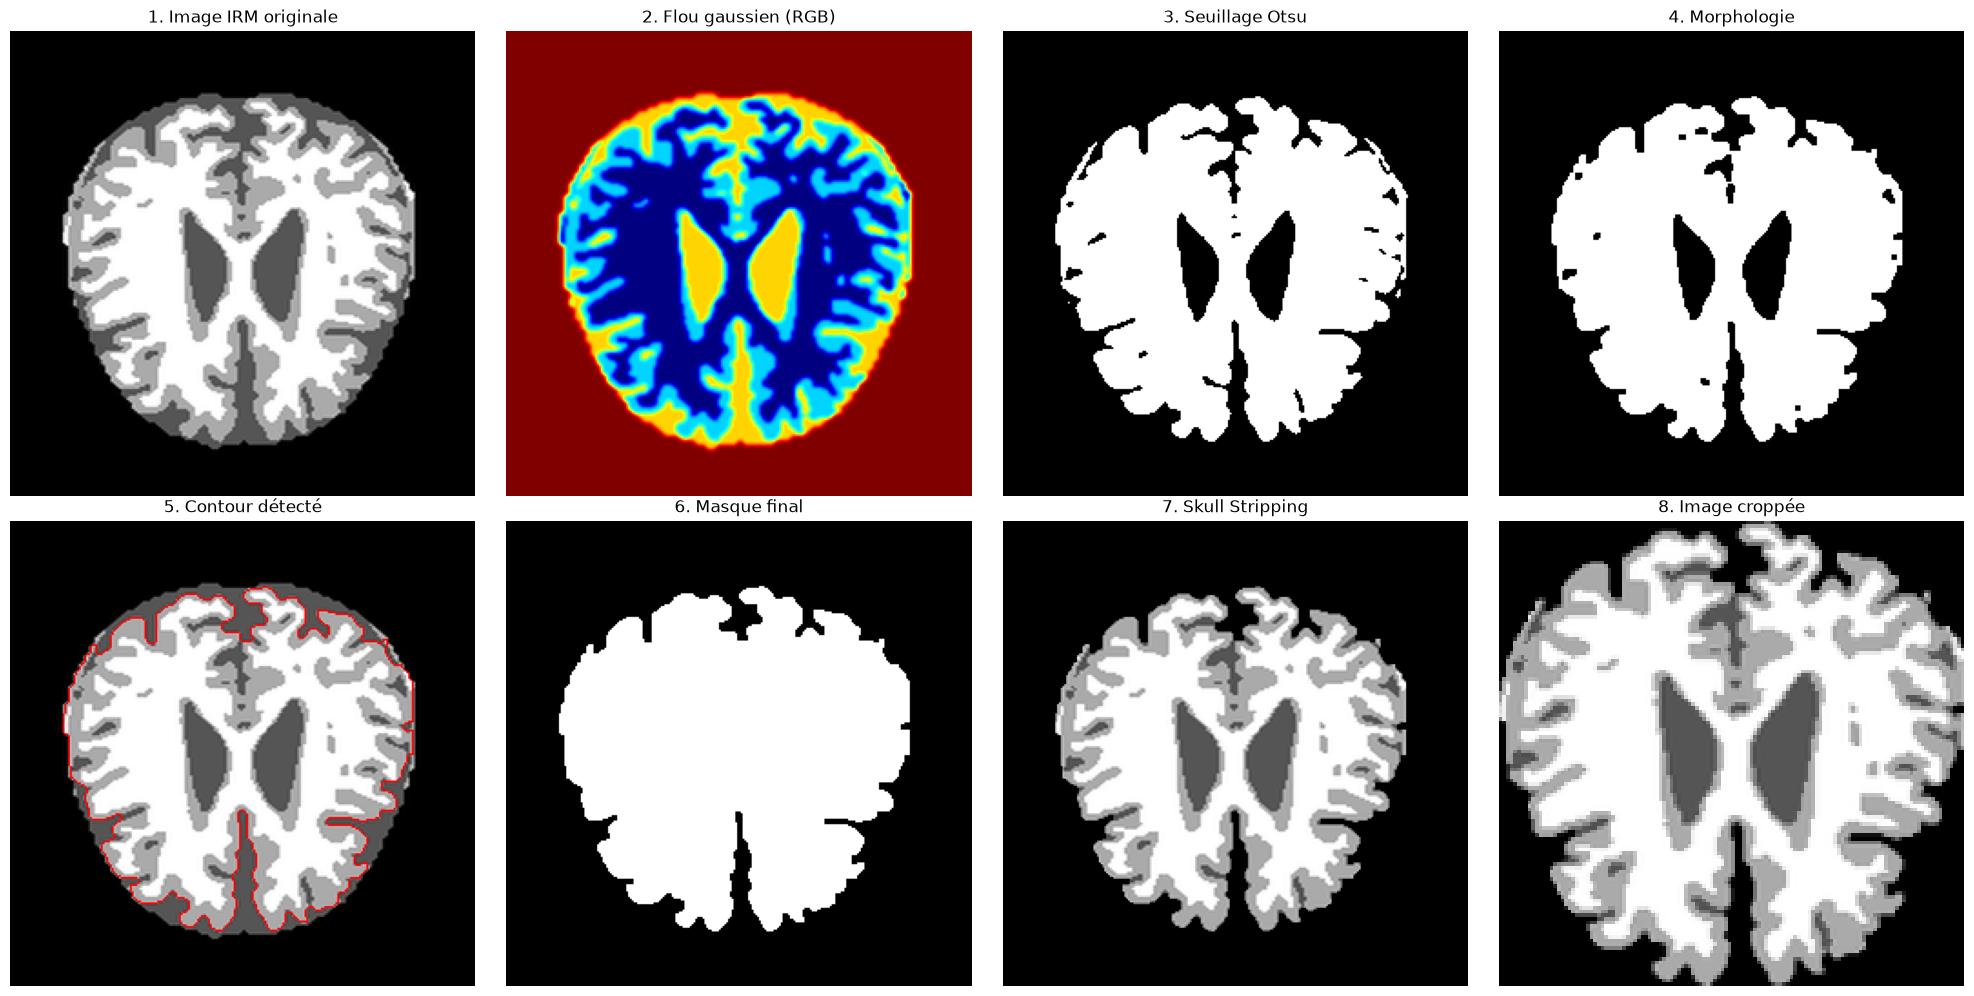

In [58]:
#2. Exploration et prétraitement des données,  Réutilisation de images IRM avec Mahdi Baccar
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

# === Chargement de l'image IRM ===
image_path = Path(
    "data/raw/Mild Demented/OAS1_0028_MR1_final/0028_nii_slice_025.png"
)
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
if img is None:
    raise ValueError("Image non trouvée.")

# === Étape 1 : Flou Gaussien ===
blurred = cv2.GaussianBlur(img, (5, 5), 0)

# === Étape 2 : Seuillage Otsu ===
_, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# === Étape 3 : Morphologie (nettoyage doux pour garder les détails) ===
kernel = np.ones((3, 3), np.uint8)
opened = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=1)
cleaned = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel, iterations=1)

# === Étape 4 : Détection des contours internes (pas juste le plus grand) ===
contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
mask = np.zeros_like(img)

# Conserver les contours situés vers le centre de l'image
for c in contours:
    M = cv2.moments(c)
    if M["m00"] == 0:
        continue
    cx = int(M["m10"] / M["m00"])
    cy = int(M["m01"] / M["m00"])
    if (img.shape[1]*0.15 < cx < img.shape[1]*0.85) and (img.shape[0]*0.15 < cy < img.shape[0]*0.85):
        cv2.drawContours(mask, [c], -1, 255, thickness=cv2.FILLED)

# === Étape 5 : Application du masque ===
brain_only = cv2.bitwise_and(img, mask)

# === Étape 6 : Cropping autour du cerveau ===
x, y, w, h = cv2.boundingRect(mask)
cropped_brain = brain_only[y:y+h, x:x+w]
cropped_resized = cv2.resize(cropped_brain, (128, 128))

# === VISUALISATION ===
blurred_rgb = cv2.applyColorMap(blurred, cv2.COLORMAP_JET)
contour_overlay = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
for c in contours:
    cv2.drawContours(contour_overlay, [c], -1, (255, 0, 0), 1)
mask_rgb = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)

fig, axs = plt.subplots(2, 4, figsize=(20, 10))
steps = [
    (img, "1. Image IRM originale", 'gray'),
    (blurred_rgb, "2. Flou gaussien (RGB)", None),
    (thresh, "3. Seuillage Otsu", 'gray'),
    (cleaned, "4. Morphologie", 'gray'),
    (contour_overlay, "5. Contour détecté", None),
    (mask_rgb, "6. Masque final", None),
    (brain_only, "7. Skull Stripping", 'gray'),
    (cropped_resized, "8. Image croppée", 'gray'),
]

for ax, (image, title, cmap) in zip(axs.ravel(), steps):
    ax.imshow(image, cmap=cmap) if cmap else ax.imshow(image)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
#3. Extraction et représentation des caractéristiques, Les images se trouvent dans le dossier data/raw,
# LBP (Local Binary Patterns) est une méthode efficace pour extraire des caractéristiques de texture à partir d'images.

from skimage.feature import local_binary_pattern

input_dir = Path("data/raw")
output_dir = Path("data/treated")
image_extensions = {".png"}
all_histograms = []

def apply_lbp(image_path: Path, output_path: Path):
    # === Lecture en niveaux de gris ===
    image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)

    if image is None:
        print(f"Image impossible à lire : {image_path}")
        return None

    # === Application du LBP ===
    # FIXME: Ajuster les paramètres ...
    lbp = local_binary_pattern(
        image,
        P=8, # nombre de point
        R=3, # rayon
        method="ror"
    )
    """
    method
    default: This is the original local binary pattern. It is grayscale invariant but not rotation invariant.
    ror: This is an extension of the default pattern and is both grayscale and rotation invariant.
    uniform: This method produces a uniform pattern that is both grayscale and rotation invariant. It offers finer quantization of the angular space, making it suitable for texture classification tasks.
    nri_uniform: This is a variant of the uniform pattern that is grayscale invariant but not rotation invariant.
    var: This method computes the variance of local image texture, which is related to contrast. It is rotation invariant but not grayscale invariant.
    """

    # === Conversion pour sauvegarder l'image LBP ===
    lbp_image = np.clip(lbp, 0, 255).astype(np.uint8)

    # === Sauvegarde de l'image ===
    output_path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(output_path), lbp_image)

    # === Calcul de l'histogramme ===
    histogram, _ = np.histogram(
        lbp.ravel(),
        bins=np.arange(257),
        range=(0, 256)
    )

    histogram = histogram.astype("float32")
    histogram /= histogram.sum() + 1e-7

    return histogram


# === Parcours récursif des images ===
for image_path in input_dir.rglob("*"):

    if image_path.is_file() and image_path.suffix.lower() in image_extensions:
        relative_path = image_path.relative_to(input_dir)
        output_path = output_dir / relative_path
        histogram = apply_lbp(image_path, output_path)

        # === Stockage de l'histogramme en mémoire et le path de l'image ===
        if histogram is not None:
            all_histograms.append({
                "image_path": str(relative_path),
                "histogram": histogram
            })

            # print(f"\nImage : {relative_path}")
            # print("Histogramme LBP :")
            # print(histogram)
            # print(f"Nombre de valeurs : {len(histogram)}")
            # print(f"Somme de l'histogramme : {histogram.sum():.4f}")


print("\nTraitement terminé.")
print(f"Nombre total d'histogrammes en RAM : {len(all_histograms)}")






Traitement terminé.
Nombre total d'histogrammes en RAM : 750


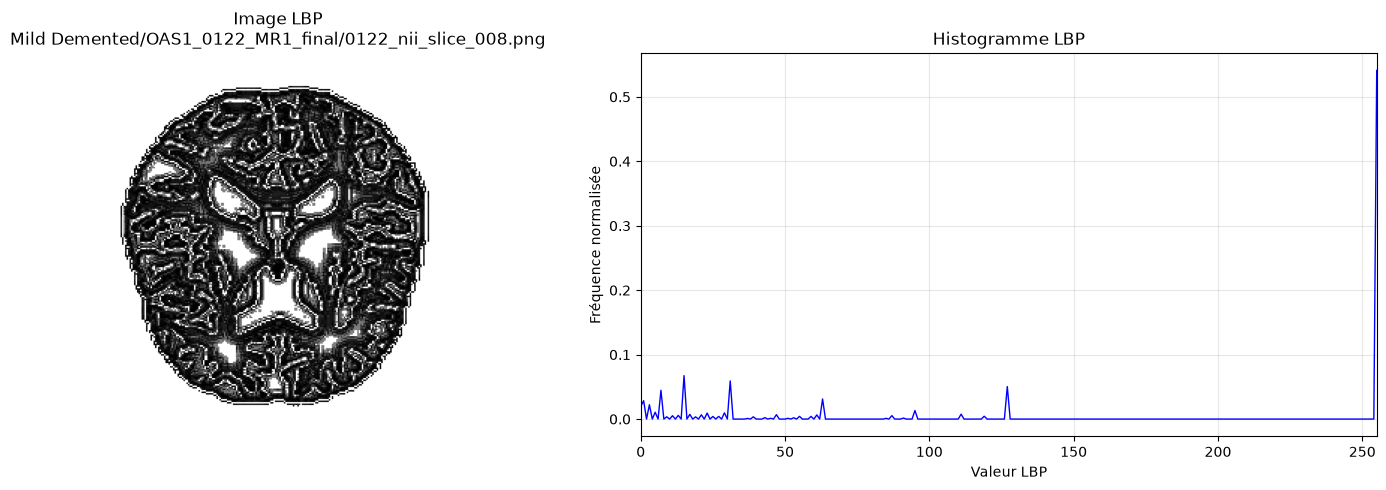

In [60]:
#3. Extraction et représentation des caractéristiques, Suite
# Exploration des histogrammes LBP et visualisation de la première image traitée

# === Récupération du premier histogramme et image traitée ===
X_ITEM = 250
premier_histogramme = all_histograms[X_ITEM]["histogram"]
premiere_image = all_histograms[X_ITEM]["image_path"]
premiere_image_path = output_dir / premiere_image


image_lbp = cv2.imread(
    str(premiere_image_path),
    cv2.IMREAD_GRAYSCALE
)
# === Affichage de l'image LBP et de l'histogramme ===
if image_lbp is None:
    print(f"Image impossible à lire : {premiere_image_path}")
else:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].imshow(image_lbp, cmap="gray")
    axes[0].set_title(f"Image LBP\n{premiere_image}")
    axes[0].axis("off")

    axes[1].plot(
        premier_histogramme,
        color="blue",
        linewidth=1
    )

    axes[1].set_title("Histogramme LBP")
    axes[1].set_xlabel("Valeur LBP")
    axes[1].set_ylabel("Fréquence normalisée")
    axes[1].set_xlim(0, 255)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()





In [61]:
# Separation des données en ensembles d'entraînement et de test

from sklearn.model_selection import train_test_split
import shutil

# === Séparation des données en ensembles d'entraînement et de test ===
data_dir = Path("data/treated")
extensions = {".png"}

images = []
labels = []

# === Séparation 70 % entraînement / 15 % test / 15 % validation ===
for classe_dir in data_dir.iterdir():
    if classe_dir.is_dir():
        for image_path in classe_dir.rglob("*"):
            if image_path.suffix.lower() in extensions:
                images.append(image_path)
                labels.append(classe_dir.name)

X_train, X_temp, y_train, y_temp = train_test_split(
    images,
    labels,
    test_size=0.30,
    random_state=42,
    stratify=labels
)

X_test, X_validation, y_test, y_validation = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

train_dir = Path("data/split/train")
test_dir = Path("data/split/test")
val_dir = Path("data/split/validation")

for image_path, label in zip(X_train, y_train):
    destination = train_dir / label
    destination.mkdir(parents=True, exist_ok=True)
    shutil.copy2(image_path, destination / image_path.name)

for image_path, label in zip(X_test, y_test):
    destination = test_dir / label
    destination.mkdir(parents=True, exist_ok=True)
    shutil.copy2(image_path, destination / image_path.name)

for image_path, label in zip(X_validation, y_validation):
    destination = val_dir / label
    destination.mkdir(parents=True, exist_ok=True)
    shutil.copy2(image_path, destination / image_path.name)

print(f"Images d'entraînement : {len(X_train)}")
print(f"Images de test : {len(X_test)}")
print(f"Images de validation : {len(X_validation)}")


Images d'entraînement : 525
Images de test : 112
Images de validation : 113


In [53]:
# from sklearn.preprocessing import OrdinalEncoder

# # Conversion des labels en tableau  https://numpy.org/doc/stable/reference/generated/numpy.reshape.html
# y_train_2d = np.array(y_train).reshape(-1, 1)
# y_test_2d = np.array(y_test).reshape(-1, 1)

# # Non Dementia       -> 0
# # Very Mild Demented -> 1
# # Mild Demented      -> 2
# encoder = OrdinalEncoder(
#     categories=[[
#         "Non Dementia",
#         "Very Mild Demented",
#         "Mild Demented"
#     ]]
# )


# # Apprentissage uniquement sur les données d'entraînement
# y_train_encoded = encoder.fit_transform(y_train_2d)

# # Application de la transformation sur les données de test
# y_test_encoded = encoder.transform(y_test_2d)


# # Conversion en vecteur 1D
# y_train_encoded = y_train_encoded.ravel().astype(int)
# y_test_encoded = y_test_encoded.ravel().astype(int)


# print("Classes originales :", encoder.categories_)
# print("y_train encodé :", y_train_encoded)
# print("y_test encodé :", y_test_encoded)


In [51]:
from sklearn.base import BaseEstimator, TransformerMixin
# https://scikit-learn.org/stable/modules/generated/sklearn.base.TransformerMixin.html
# === Transformation de chaque image en vecteur de pixels ===
class ImageToPixels(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        images = []

        for image_path in X:
            image = cv2.imread(
                str(image_path),
                cv2.IMREAD_GRAYSCALE
            )

            if image is None:
                raise ValueError(
                    f"Impossible de lire l'image : {image_path}"
                )

            image_array = image.astype(np.float32) / 255.0
            image_vector = image_array.flatten()
            images.append(image_vector)

        return np.asarray(images, dtype=np.float32)


In [67]:
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score


# Pipeline SVM  
# https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html
# FIXME: Ajuster les paramètres ...
svm_pipeline = Pipeline([
    ("image_to_pixels", ImageToPixels()),
    ("scaler", StandardScaler()),
    ("PCA", PCA(
        n_components=0.95,
        svd_solver="auto",
        power_iteration_normalizer="auto",
    )),  # Réduction de dimensionnalité à 95%
    ("svm", SVC(
        kernel="rbf",
        C=10,
        gamma="scale",
        coef0=0.0,
        shrinking=True,
        probability=False,
        tol=1e-3,
        cache_size=200,
        class_weight=None,
        max_iter=-1,
        random_state=None,
    ))
])

# Entraînement uniquement sur les données train
svm_pipeline.fit(
    X_train,
    y_train
)


/home/dupp/GIT/machine-learning/tp1/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('image_to_pixels', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[<U18](3,)","['Mild Demented','Non Dementia','Very Mild Demented']"
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value
"mean_ mean_: ndarray of shape (n_features,) or NoneThe mean value for each feature in the training set.Equal to ``None`` when ``with_mean=False`` and ``with_std=False``.","ndarray[float64](65536,)","[1.,1.,1.,...,1.,1.,1.]"


In [68]:
# Prédiction sur les données test
y_validation_pred = svm_pipeline.predict(X_validation)

print("Résultats sur l'ensemble de validation")
print("Accuracy :", accuracy_score(y_validation, y_validation_pred))

print("\nRapport de classification :")
print(
    classification_report(
        y_validation,
        y_validation_pred
    )
)

Résultats sur l'ensemble de validation
Accuracy : 0.9646017699115044

Rapport de classification :
                    precision    recall  f1-score   support

     Mild Demented       0.95      0.95      0.95        37
      Non Dementia       1.00      0.95      0.97        38
Very Mild Demented       0.95      1.00      0.97        38

          accuracy                           0.96       113
         macro avg       0.97      0.96      0.96       113
      weighted avg       0.97      0.96      0.96       113

